In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [19]:
df = pd.read_csv("titanic.csv")

# pd.read_csv => get data from csv file, make into pandas dataframe object

In [20]:
df.head() # shows first 5 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [21]:
df.shape # returns (num rows, num cols) as a tuple

(891, 12)

In [22]:
df.info() # shows data types

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [28]:
df.isnull().sum() # Finds number of missing (null) values for each column


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [34]:
df.fillna({'Embarked': 'S'}, inplace=True)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C


In [35]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [36]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

Data is cleaned properly now

Time to plot it out

https://matplotlib.org/stable/tutorials/pyplot.html For pyplot tutorial

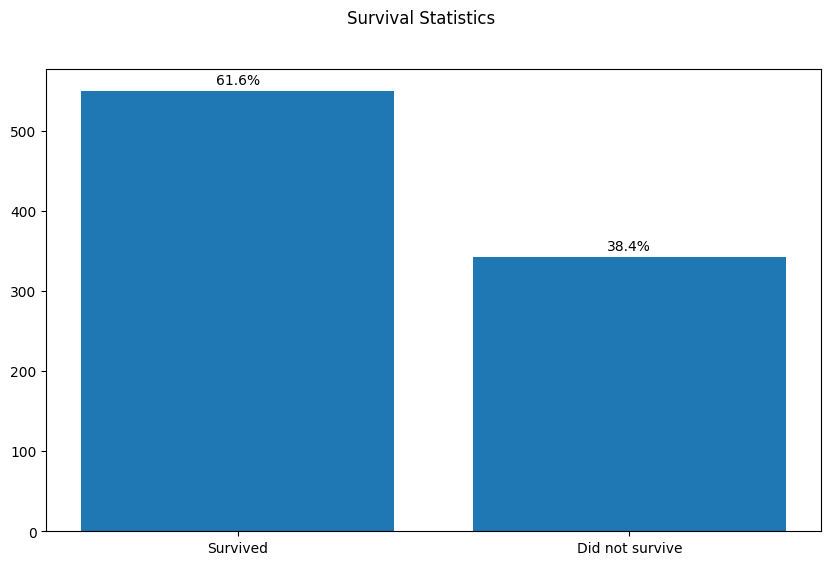

In [37]:
# We want to create a graph based on categorical variable (survived)

plt.figure(figsize=(10, 6))

count_zero = (df.Survived == 0).sum() # Num zeros
count_one = (df.Survived == 1).sum() # Num ones
total = count_zero + count_one

names = ['Survived', 'Did not survive']
values = [count_zero, count_one]

bars = plt.bar(names, values) # Create a bar graph with survived statistics

for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100
    plt.annotate(f'{percentage:.1f}%',
                 xy=(bar.get_x() + bar.get_width() / 2, height), 
                 xytext=(0, 3),
                 textcoords="offset points", ha='center', va='bottom')

plt.suptitle('Survival Statistics')   
plt.show()
    


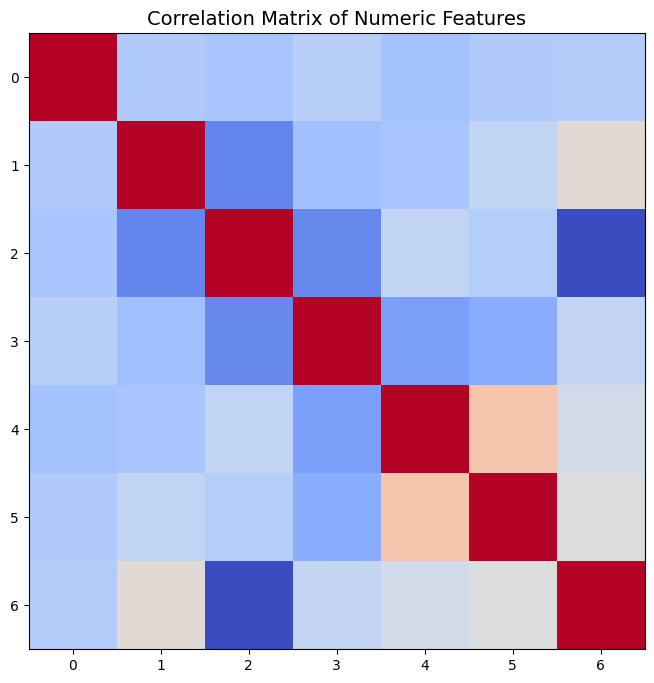


Correlation with Survival:
Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.069809
Pclass        -0.338481
Name: Survived, dtype: float64


In [38]:
# Calculate correlation matrix for numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm')

plt.title('Correlation Matrix of Numeric Features', fontsize=14)
plt.show()

print("\nCorrelation with Survival:")
print(correlation_matrix['Survived'].sort_values(ascending=False))

# Survived (0 for died, 1 for survived)
# Parch (# of parents and children aboard)
# SibSp: Number of siblings
# PassengerId: Passenger ID
# PClass: 1 = First class, 2 = Second class, 3 = Third class

For categorical variables (sex in this case), one-hot encoding is used, meaning you add two new rows (is_male for men and is_female for women)

In [39]:
categorical_columns = ["Sex", "Embarked"]# Select all objects (categorical)

df_encoded = df.copy()

df_encoded = df.drop(columns=["Name", "Ticket", "PassengerId"])

df_encoded = pd.get_dummies(df_encoded, columns=categorical_columns, drop_first=True)

print("\nFinal encoded categorical columns:")
print([col for col in df_encoded.columns if any(cat in col for cat in categorical_columns)])

df_encoded.head()





Final encoded categorical columns:
['Sex_male', 'Embarked_Q', 'Embarked_S']


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [42]:
X = df_encoded.drop("Survived", axis=1)
print(X.head())
y = df_encoded["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, solver="liblinear"))
])

model.fit(X_train, y_train)

model.predict(X_test)

model.score(X_test, y_test)



   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  22.0      1      0   7.2500      True       False        True
1       1  38.0      1      0  71.2833     False       False       False
2       3  26.0      0      0   7.9250     False       False        True
3       1  35.0      1      0  53.1000     False       False        True
4       3  35.0      0      0   8.0500      True       False        True


0.8100558659217877